In [1]:
# ==========================================================
# MINI PROJECT 3
# HAWKES PROCESS OF MID-PRICE JUMPS
# PART 1
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from google.colab import files

# ==========================================================
# STEP 1 : Upload Dataset
# ==========================================================

uploaded = files.upload()

filename = list(uploaded.keys())[0]

depth = pd.read_csv(filename)

# ==========================================================
# STEP 2 : Data Preparation
# ==========================================================

depth["timestamp"] = pd.to_datetime(depth["timestamp"])

depth = depth.sort_values("timestamp").reset_index(drop=True)

# Remove crossed quotes

depth = depth[
    depth["best_ask"] >= depth["best_bid"]
].copy()

depth.reset_index(drop=True, inplace=True)

print("Rows after cleaning :", len(depth))

# ==========================================================
# STEP 3 : Mid Price
# ==========================================================

depth["mid_price"] = (
    depth["best_bid"] +
    depth["best_ask"]
) / 2

# ==========================================================
# STEP 4 : Mid Price Return
# ==========================================================

depth["mid_return"] = depth["mid_price"].pct_change()

depth = depth.dropna().reset_index(drop=True)

# ==========================================================
# STEP 5 : Define Jump Events
# ==========================================================

threshold = (
    3 *
    depth["mid_return"].std()
)

print("Jump Threshold :", threshold)

depth["jump_event"] = (
    np.abs(depth["mid_return"]) >
    threshold
).astype(int)

events = depth[
    depth["jump_event"] == 1
].copy()

print("Number of Jump Events :", len(events))

# ==========================================================
# STEP 6 : Event Times
# ==========================================================

event_times = (
    events["timestamp"] -
    depth["timestamp"].iloc[0]
).dt.total_seconds().values

T = event_times[-1]

print("Observation Time :", T)

# ==========================================================
# STEP 7 : Recursive Hawkes Log-Likelihood
# ==========================================================

def negative_log_likelihood(params):

    mu, alpha, beta = params

    if mu <= 0 or alpha <= 0 or beta <= 0:
        return np.inf

    n = len(event_times)

    R = np.zeros(n)

    for i in range(1, n):

        dt = event_times[i] - event_times[i-1]

        R[i] = np.exp(-beta * dt) * (1 + R[i-1])

    intensity = mu + alpha * R

    if np.any(intensity <= 0):
        return np.inf

    loglik = np.sum(np.log(intensity))

    compensator = (
        mu * T +
        (alpha / beta) *
        np.sum(
            1 -
            np.exp(
                -beta *
                (T - event_times)
            )
        )
    )

    return -(loglik - compensator)

# ==========================================================
# STEP 8 : Parameter Estimation
# ==========================================================

result = minimize(

    negative_log_likelihood,

    x0=[0.10,0.20,1.00],

    method="L-BFGS-B",

    bounds=[
        (1e-6,None),
        (1e-6,None),
        (1e-6,None)
    ]

)

mu_hat, alpha_hat, beta_hat = result.x

print("\nOptimization Completed")

print("---------------------------")

print("Success :", result.success)

print("Message :", result.message)

print()

print("Estimated Parameters")

print("---------------------------")

print("mu    :", mu_hat)

print("alpha :", alpha_hat)

print("beta  :", beta_hat)

Saving BTCUSDT_Depth_1Hour.csv to BTCUSDT_Depth_1Hour.csv
Rows after cleaning : 31422
Jump Threshold : 0.045808563902405036
Number of Jump Events : 21
Observation Time : 3596.475

Optimization Completed
---------------------------
Success : True
Message : CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL

Estimated Parameters
---------------------------
mu    : 0.00583904573266314
alpha : 1e-06
beta  : 5.306931643523629


Hawkes intensity computed successfully.
Poisson Intensity: 0.005839050737180156
                  Metric        Value
0  Number of Jump Events    21.000000
1       Observation Time  3596.475000
2            Estimated μ     0.005839
3            Estimated α     0.000001
4            Estimated β     5.306932
5              Poisson λ     0.005839


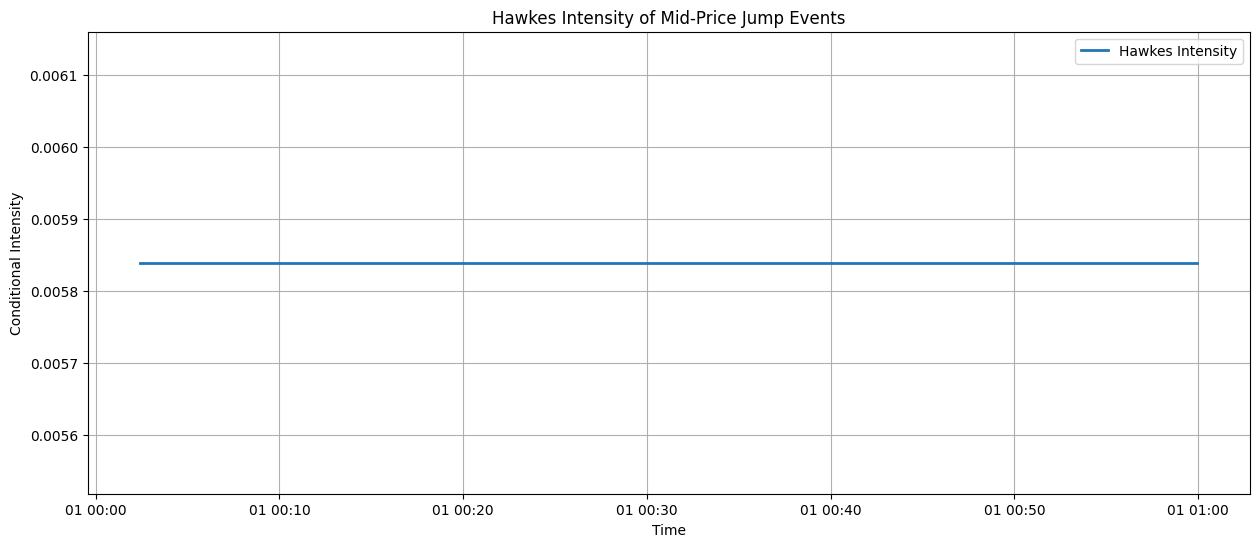

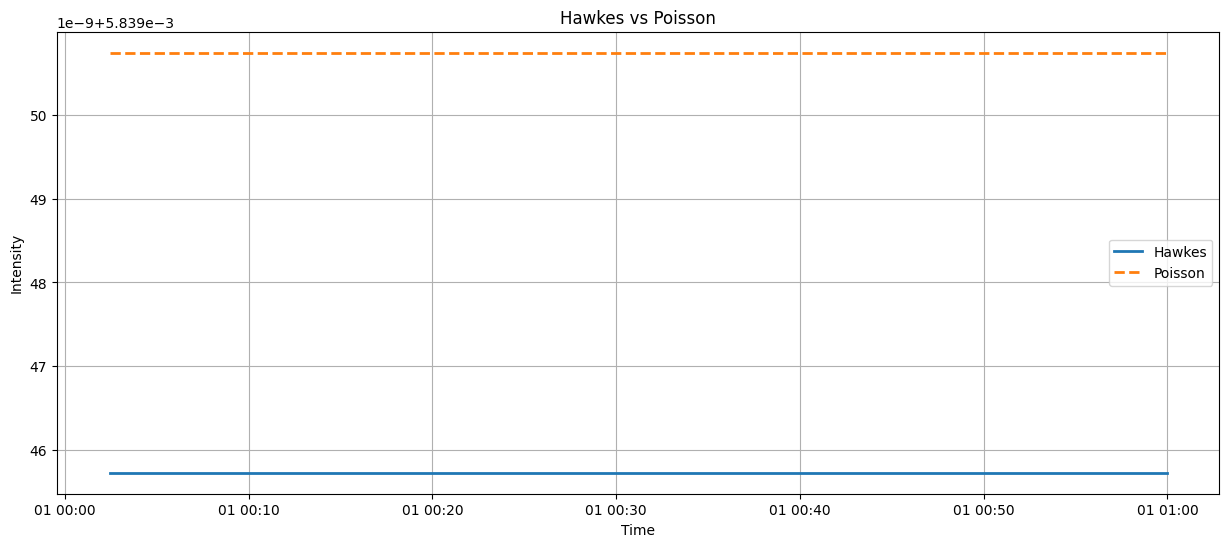

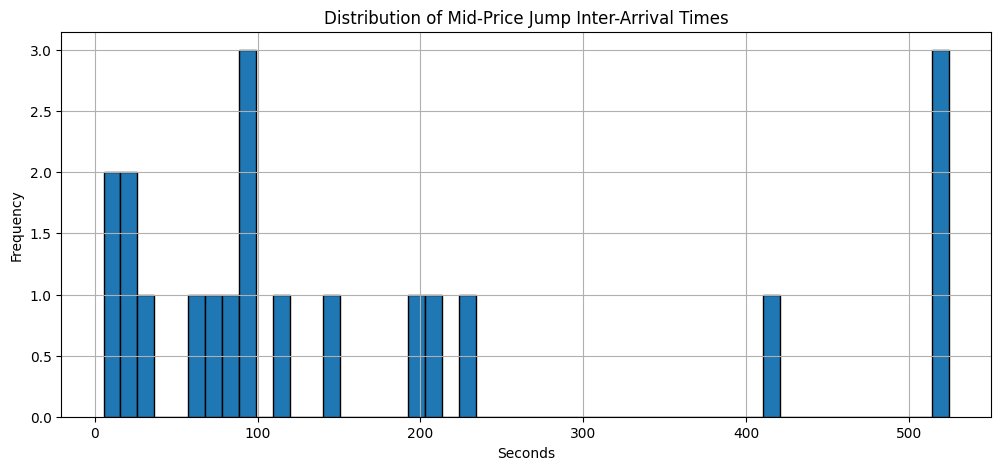


MODEL COMPARISON
     Model  LogLikelihood         AIC         BIC
0  Poisson    -129.006928  260.013856  261.058378
1   Hawkes    -129.006932  264.013863  267.147431

Likelihood Ratio Statistic: -7.5373275763013226e-06

INTERPRETATION
Weak self-excitation detected.
Poisson model outperforms the Hawkes model based on AIC.
Poisson model outperforms the Hawkes model based on BIC.
Likelihood Ratio Test does not provide strong evidence in favor of the Hawkes model.

Mini Project 3 Completed Successfully.


In [2]:
# ==========================================================
# PART 2
# HAWKES INTENSITY
# ==========================================================

n = len(event_times)

R = np.zeros(n)

hawkes_intensity = np.zeros(n)

hawkes_intensity[0] = mu_hat

for i in range(1, n):

    dt = event_times[i] - event_times[i-1]

    R[i] = np.exp(-beta_hat * dt) * (1 + R[i-1])

    hawkes_intensity[i] = mu_hat + alpha_hat * R[i]

events["hawkes_intensity"] = hawkes_intensity

print("Hawkes intensity computed successfully.")

# ==========================================================
# POISSON MODEL
# ==========================================================

poisson_lambda = len(event_times) / T

events["poisson_intensity"] = poisson_lambda

print("Poisson Intensity:", poisson_lambda)

# ==========================================================
# SUMMARY TABLE
# ==========================================================

summary = pd.DataFrame({

    "Metric":[

        "Number of Jump Events",

        "Observation Time",

        "Estimated μ",

        "Estimated α",

        "Estimated β",

        "Poisson λ"

    ],

    "Value":[

        len(event_times),

        T,

        mu_hat,

        alpha_hat,

        beta_hat,

        poisson_lambda

    ]

})

print(summary)

# ==========================================================
# HAWKES INTENSITY PLOT
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(

    events["timestamp"],

    events["hawkes_intensity"],

    linewidth=2,

    label="Hawkes Intensity"

)

plt.title("Hawkes Intensity of Mid-Price Jump Events")

plt.xlabel("Time")

plt.ylabel("Conditional Intensity")

plt.grid(True)

plt.legend()

plt.show()

# ==========================================================
# HAWKES VS POISSON
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(

    events["timestamp"],

    events["hawkes_intensity"],

    linewidth=2,

    label="Hawkes"

)

plt.plot(

    events["timestamp"],

    events["poisson_intensity"],

    "--",

    linewidth=2,

    label="Poisson"

)

plt.title("Hawkes vs Poisson")

plt.xlabel("Time")

plt.ylabel("Intensity")

plt.grid(True)

plt.legend()

plt.show()

# ==========================================================
# INTER-ARRIVAL TIMES
# ==========================================================

plt.figure(figsize=(12,5))

plt.hist(

    np.diff(event_times),

    bins=50,

    edgecolor="black"

)

plt.title("Distribution of Mid-Price Jump Inter-Arrival Times")

plt.xlabel("Seconds")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

# ==========================================================
# MODEL COMPARISON
# ==========================================================

R = np.zeros(n)

for i in range(1, n):

    dt = event_times[i] - event_times[i-1]

    R[i] = np.exp(-beta_hat * dt) * (1 + R[i-1])

hawkes_intensity = mu_hat + alpha_hat * R

hawkes_loglik = np.sum(np.log(hawkes_intensity))

hawkes_loglik -= (

    mu_hat * T +

    (alpha_hat / beta_hat) *

    np.sum(

        1 -

        np.exp(

            -beta_hat *

            (T - event_times)

        )

    )

)

lambda_hat = len(event_times) / T

poisson_loglik = (

    len(event_times) *

    np.log(lambda_hat)

    -

    lambda_hat * T

)

hawkes_aic = 2 * 3 - 2 * hawkes_loglik

poisson_aic = 2 * 1 - 2 * poisson_loglik

hawkes_bic = np.log(len(event_times)) * 3 - 2 * hawkes_loglik

poisson_bic = np.log(len(event_times)) * 1 - 2 * poisson_loglik

lrt = 2 * (hawkes_loglik - poisson_loglik)

comparison = pd.DataFrame({

    "Model":[

        "Poisson",

        "Hawkes"

    ],

    "LogLikelihood":[

        poisson_loglik,

        hawkes_loglik

    ],

    "AIC":[

        poisson_aic,

        hawkes_aic

    ],

    "BIC":[

        poisson_bic,

        hawkes_bic

    ]

})

print("\n==============================")

print("MODEL COMPARISON")

print("==============================")

print(comparison)

print("\nLikelihood Ratio Statistic:", lrt)

# ==========================================================
# INTERPRETATION
# ==========================================================

print("\n==============================")

print("INTERPRETATION")

print("==============================")

if alpha_hat > mu_hat:

    print("Strong self-excitation detected.")

else:

    print("Weak self-excitation detected.")

if hawkes_aic < poisson_aic:

    print("Hawkes model outperforms the Poisson model based on AIC.")

else:

    print("Poisson model outperforms the Hawkes model based on AIC.")

if hawkes_bic < poisson_bic:

    print("Hawkes model outperforms the Poisson model based on BIC.")

else:

    print("Poisson model outperforms the Hawkes model based on BIC.")

if lrt > 3.84:

    print("Likelihood Ratio Test indicates the Hawkes model provides a statistically superior fit.")

else:

    print("Likelihood Ratio Test does not provide strong evidence in favor of the Hawkes model.")

print("\nMini Project 3 Completed Successfully.")